In [1]:
#Imports

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
import torch.optim as optim
from sklearn.preprocessing import StandardScaler
from google.colab import files

In [2]:
uploaded = files.upload()

Saving gender_classification_v7.csv to gender_classification_v7.csv


In [4]:
# DataFrame

df = pd.read_csv("gender_classification_v7.csv")

In [5]:
# DF - Info

print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5001 entries, 0 to 5000
Data columns (total 8 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   long_hair                  5001 non-null   int64  
 1   forehead_width_cm          5001 non-null   float64
 2   forehead_height_cm         5001 non-null   float64
 3   nose_wide                  5001 non-null   int64  
 4   nose_long                  5001 non-null   int64  
 5   lips_thin                  5001 non-null   int64  
 6   distance_nose_to_lip_long  5001 non-null   int64  
 7   gender                     5001 non-null   object 
dtypes: float64(2), int64(5), object(1)
memory usage: 312.7+ KB
None


In [6]:
# DF - Value Counts

print(df['gender'].value_counts())

gender
Female    2501
Male      2500
Name: count, dtype: int64


In [7]:
# Removing 'Gender'

df_clean = df.drop(columns=['gender'])

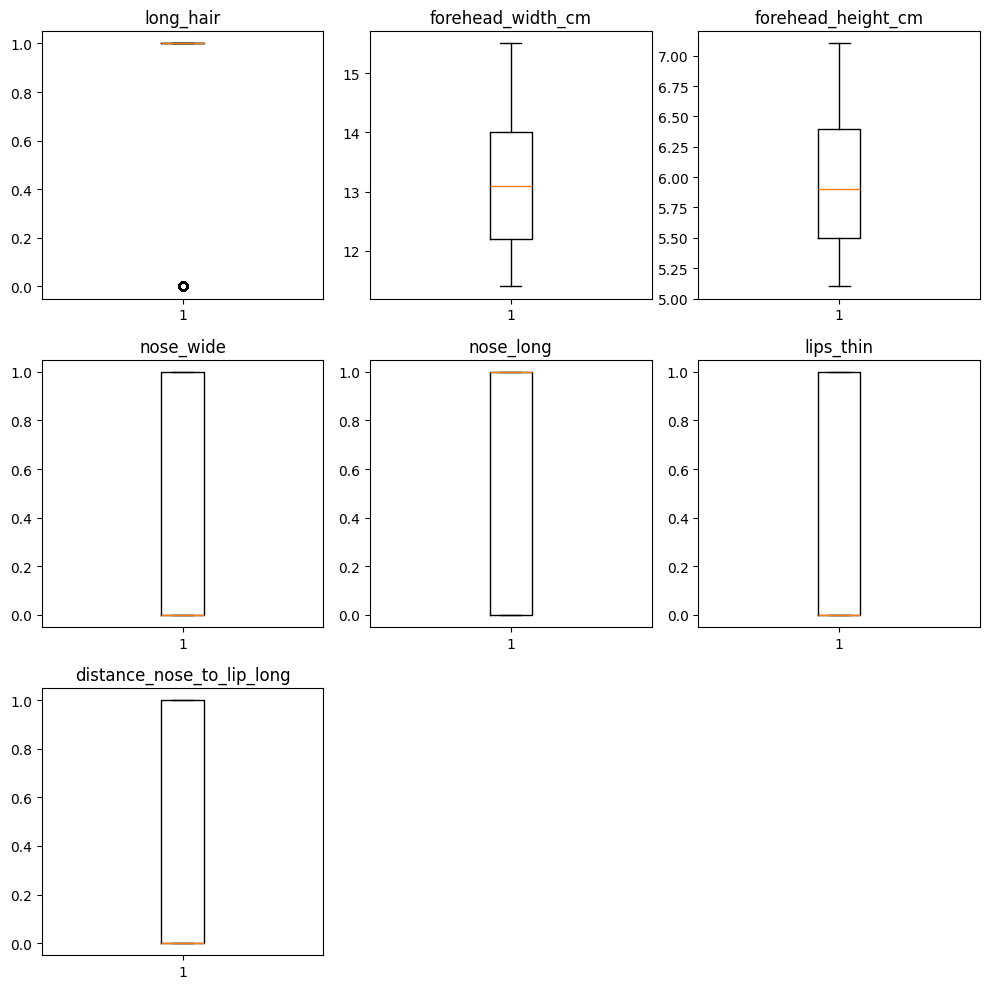

In [10]:
# Boxplot

cols = df_clean.columns
n_rows = 3
n_cols = 3

plt.figure(figsize=(10, 10))
for i, col in enumerate(cols):
    plt.subplot(n_rows, n_cols, i+1)
    plt.boxplot(df_clean[col])
    plt.title(col)
plt.tight_layout()
plt.show()

In [11]:
#Train, Test and Val Split

X = df.drop(columns=['gender'])
y = (df['gender'] == 'Male').astype(int)

X_train2, X_temp, y_train2, y_temp = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

X_val2, X_test2, y_val2, y_test2 = train_test_split(
    X_temp, y_temp,
    test_size=0.5,
    random_state=42,
    stratify=y_temp
)

In [12]:
#StandardScaler

scaler = StandardScaler()

X_train2 = scaler.fit_transform(X_train2)
X_val2 = scaler.transform(X_val2)
X_test2 = scaler.transform(X_test2)

In [13]:
# Convert to Tensor

X_train = torch.tensor(X_train2, dtype=torch.float32)
y_train = torch.tensor(y_train2.values, dtype=torch.float32).view(-1, 1)

X_val = torch.tensor(X_val2, dtype=torch.float32)
y_val   = torch.tensor(y_val2.values, dtype=torch.float32).view(-1, 1)

X_test = torch.tensor(X_test2, dtype=torch.float32)
y_test  = torch.tensor(y_test2.values, dtype=torch.float32).view(-1, 1)

In [14]:
# DataLoader

batch_size = 64

train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=batch_size, shuffle=True)
val_loader = DataLoader(TensorDataset(X_val, y_val), batch_size=batch_size, shuffle=False)
test_loader = DataLoader(TensorDataset(X_test, y_test), batch_size=batch_size, shuffle=False)

In [15]:
# MLP

class MLP(nn.Module):
    def __init__(self):
        super().__init__()

        self.model = nn.Sequential(
            nn.Linear(7, 32),
            nn.LeakyReLU(negative_slope=0.01),

            nn.Linear(32, 1)
        )

    def forward(self, x):
        return self.model(x)

model = MLP()
print(model)

MLP(
  (model): Sequential(
    (0): Linear(in_features=7, out_features=32, bias=True)
    (1): LeakyReLU(negative_slope=0.01)
    (2): Linear(in_features=32, out_features=1, bias=True)
  )
)


In [16]:
# Criterion and Optimizer

criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=0.01)

In [17]:
# Training MLP model

train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

for epoch in range(500):

    # Train
    model.train()
    train_loss_epoch = 0
    train_acc_epoch = 0

    for X_batch, y_batch in train_loader:

        output = model(X_batch)
        loss = criterion(output, y_batch)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss_epoch += loss.item()

        preds = (torch.sigmoid(output) > 0.5).float()
        acc = (preds == y_batch).float().mean() * 100
        train_acc_epoch += acc.item()

    train_loss_epoch /= len(train_loader)
    train_acc_epoch /= len(train_loader)

    train_losses.append(train_loss_epoch)
    train_accuracies.append(train_acc_epoch)

    # Val
    model.eval()
    val_loss_epoch = 0
    val_acc_epoch = 0

    with torch.no_grad():
        for X_batch, y_batch in val_loader:

            output = model(X_batch)
            loss = criterion(output, y_batch)

            val_loss_epoch += loss.item()

            preds = (torch.sigmoid(output) > 0.5).float()
            acc = (preds == y_batch).float().mean() * 100
            val_acc_epoch += acc.item()

    val_loss_epoch /= len(val_loader)
    val_acc_epoch /= len(val_loader)

    val_losses.append(val_loss_epoch)
    val_accuracies.append(val_acc_epoch)

    if epoch % 10 == 0:
        print(f"Epoch {epoch:03d} | "
              f"Train Loss: {train_loss_epoch:.4f} | "
              f"Train Acc: {train_acc_epoch:.4f} | "
              f"Val Loss: {val_loss_epoch:.4f} | "
              f"Val Acc: {val_acc_epoch:.4f}")

Epoch 000 | Train Loss: 0.6147 | Train Acc: 75.9401 | Val Loss: 0.5014 | Val Acc: 93.1273
Epoch 010 | Train Loss: 0.0859 | Train Acc: 97.1746 | Val Loss: 0.0852 | Val Acc: 96.9543
Epoch 020 | Train Loss: 0.0821 | Train Acc: 96.8053 | Val Loss: 0.0824 | Val Acc: 96.9543
Epoch 030 | Train Loss: 0.0822 | Train Acc: 96.9473 | Val Loss: 0.0823 | Val Acc: 96.9543
Epoch 040 | Train Loss: 0.0820 | Train Acc: 96.9189 | Val Loss: 0.0821 | Val Acc: 96.9543
Epoch 050 | Train Loss: 0.0817 | Train Acc: 96.8208 | Val Loss: 0.0821 | Val Acc: 96.9543
Epoch 060 | Train Loss: 0.0816 | Train Acc: 96.8079 | Val Loss: 0.0819 | Val Acc: 96.8240
Epoch 070 | Train Loss: 0.0817 | Train Acc: 96.7485 | Val Loss: 0.0821 | Val Acc: 97.2147
Epoch 080 | Train Loss: 0.0814 | Train Acc: 96.7769 | Val Loss: 0.0817 | Val Acc: 96.9543
Epoch 090 | Train Loss: 0.0814 | Train Acc: 97.1591 | Val Loss: 0.0818 | Val Acc: 97.0845
Epoch 100 | Train Loss: 0.0818 | Train Acc: 96.8053 | Val Loss: 0.0816 | Val Acc: 97.0845
Epoch 110 

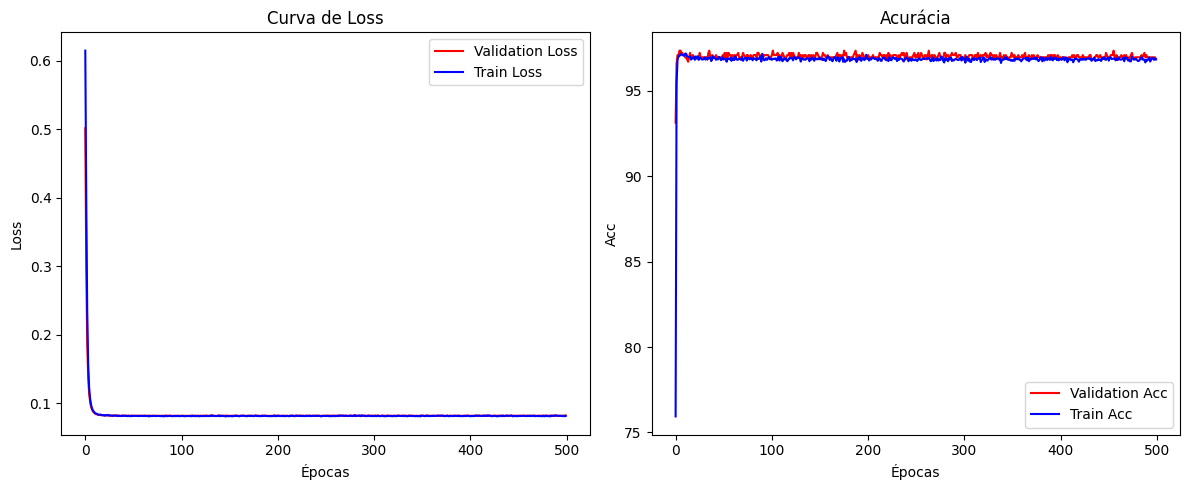

In [18]:
# Loss Curve and Accuracy curve (Train and Val)

fig, axes = plt.subplots(1, 2, figsize=(12,5))

# Loss
axes[0].plot(val_losses, color='red', label='Validation Loss')
axes[0].plot(train_losses, color='blue', label='Train Loss')
axes[0].set_title("Curva de Loss")
axes[0].set_xlabel("Épocas")
axes[0].set_ylabel("Loss")
axes[0].legend()

# Acc
axes[1].plot(val_accuracies, color='red', label='Validation Acc')
axes[1].plot(train_accuracies, color='blue', label='Train Acc')
axes[1].set_title("Acurácia")
axes[1].set_xlabel("Épocas")
axes[1].set_ylabel("Acc")
axes[1].legend()

plt.tight_layout()
plt.show()

In [19]:
# Test

model.eval()
test_loss = 0
test_acc = 0

with torch.no_grad():
    for X_batch, y_batch in test_loader:

        output = model(X_batch)
        loss = criterion(output, y_batch)

        test_loss += loss.item()

        preds = (torch.sigmoid(output) > 0.5).float()
        acc = (preds == y_batch).float().mean()
        test_acc += acc.item()

test_loss /= len(test_loader)
test_acc /= len(test_loader)

print(f"\nFinal Test Loss: {test_loss:.4f}")
print(f"Final Test Accuracy: {test_acc:.4f}")


Final Test Loss: 0.0773
Final Test Accuracy: 0.9709
